# Mouse Dynamics Bot Detection - Part 2: Feature Engineering

This notebook extracts comprehensive features from mouse movement data for bot detection.

**Features Categories:**
- Kinematic (speed, acceleration, jerk)
- Spatial (path straightness, curvature, angles)
- Temporal (duration, event rate, pauses)
- Behavioral (clicks, scrolls, direction changes)

In [16]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

BASE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

print(f"Working directory: {BASE_DIR}")

Working directory: /Users/karennurlybekov/Desktop/mousedynamics


## 1. Load Processed Data

In [17]:
# Load sessions from previous notebook
with open(os.path.join(OUTPUT_DIR, 'sessions_data.pkl'), 'rb') as f:
    sessions_data = pickle.load(f)

print(f"Loaded {len(sessions_data)} sessions")

Loaded 150 sessions


## 2. Feature Extraction Functions

In [18]:
def compute_distances(x, y):
    """Compute Euclidean distances between consecutive points"""
    if len(x) < 2:
        return np.array([])
    dx = np.diff(x)
    dy = np.diff(y)
    return np.sqrt(dx**2 + dy**2)

def compute_speeds(distances, time_interval=0.01):
    """Compute speeds (distance per time unit)"""
    return distances / time_interval if time_interval > 0 else distances

def compute_accelerations(speeds):
    """Compute accelerations from speeds"""
    if len(speeds) < 2:
        return np.array([])
    return np.diff(speeds)

def compute_jerks(accelerations):
    """Compute jerk (rate of acceleration change)"""
    if len(accelerations) < 2:
        return np.array([])
    return np.diff(accelerations)

In [19]:
def compute_angles(x, y):
    """Compute angles between consecutive segments"""
    if len(x) < 3:
        return np.array([])

    angles = []
    for i in range(len(x) - 2):
        v1 = np.array([x[i+1] - x[i], y[i+1] - y[i]])
        v2 = np.array([x[i+2] - x[i+1], y[i+2] - y[i+1]])
        norm1, norm2 = np.linalg.norm(v1), np.linalg.norm(v2)
        if norm1 > 0 and norm2 > 0:
            cos_angle = np.dot(v1, v2) / (norm1 * norm2)
            cos_angle = np.clip(cos_angle, -1, 1)
            angles.append(np.arccos(cos_angle))
    return np.array(angles)

def compute_curvature(x, y):
    """Compute curvature at each point"""
    if len(x) < 3:
        return np.array([])

    dx = np.gradient(x)
    dy = np.gradient(y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    numerator = np.abs(dx * ddy - dy * ddx)
    denominator = (dx**2 + dy**2)**1.5
    curvature = np.where(denominator > 1e-10, numerator / denominator, 0)
    return curvature

def compute_path_straightness(x, y):
    """Compute ratio of direct distance to total path length"""
    if len(x) < 2:
        return 0
    direct_dist = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)
    distances = compute_distances(x, y)
    total_length = np.sum(distances) if len(distances) > 0 else 0
    return direct_dist / total_length if total_length > 0 else 0

In [20]:
def safe_stat(arr, func, default=0):
    """Safely compute a statistic on an array"""
    if len(arr) == 0:
        return default
    result = func(arr)
    if np.isnan(result) or np.isinf(result):
        return default
    return result

def compute_entropy(values, bins=20):
    """Compute entropy of a distribution"""
    if len(values) < 2:
        return 0
    hist, _ = np.histogram(values, bins=bins, density=True)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return 0
    return entropy(hist)

## 3. Complete Feature Extraction

In [21]:
def extract_features(events):
    """Extract all features from a session's events"""
    features = {}

    # Separate event types
    moves = [(e['x'], e['y']) for e in events if e['type'] == 'move']
    clicks = [e for e in events if e['type'] == 'click']
    scrolls = [e for e in events if e['type'] == 'scroll']

    if len(moves) < 5:
        return None

    x = np.array([m[0] for m in moves])
    y = np.array([m[1] for m in moves])

    # Compute intermediate values
    distances = compute_distances(x, y)
    speeds = compute_speeds(distances)
    accelerations = compute_accelerations(speeds)
    jerks = compute_jerks(accelerations)
    angles = compute_angles(x, y)
    curvature = compute_curvature(x, y)

    # === KINEMATIC FEATURES ===
    features['mean_speed'] = safe_stat(speeds, np.mean)
    features['std_speed'] = safe_stat(speeds, np.std)
    features['max_speed'] = safe_stat(speeds, np.max)
    features['min_speed'] = safe_stat(speeds, np.min)
    features['median_speed'] = safe_stat(speeds, np.median)
    features['speed_range'] = features['max_speed'] - features['min_speed']

    features['mean_acceleration'] = safe_stat(accelerations, np.mean)
    features['std_acceleration'] = safe_stat(accelerations, np.std)
    features['max_acceleration'] = safe_stat(accelerations, lambda a: np.max(np.abs(a)))

    features['mean_jerk'] = safe_stat(jerks, np.mean)
    features['std_jerk'] = safe_stat(jerks, np.std)

    # === SPATIAL FEATURES ===
    features['path_straightness'] = compute_path_straightness(x, y)
    features['total_path_length'] = np.sum(distances) if len(distances) > 0 else 0
    features['direct_distance'] = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)

    features['mean_curvature'] = safe_stat(curvature, np.mean)
    features['std_curvature'] = safe_stat(curvature, np.std)
    features['max_curvature'] = safe_stat(curvature, np.max)

    features['mean_angle_change'] = safe_stat(angles, np.mean)
    features['std_angle_change'] = safe_stat(angles, np.std)

    # X and Y range
    features['x_range'] = np.max(x) - np.min(x)
    features['y_range'] = np.max(y) - np.min(y)
    features['aspect_ratio'] = features['x_range'] / features['y_range'] if features['y_range'] > 0 else 0

    # === TEMPORAL FEATURES ===
    features['num_events'] = len(events)
    features['num_moves'] = len(moves)
    features['session_duration'] = len(moves) * 0.01  # Estimated
    features['event_rate'] = len(events) / max(features['session_duration'], 0.001)

    features['mean_distance'] = safe_stat(distances, np.mean)
    features['std_distance'] = safe_stat(distances, np.std)
    features['distance_entropy'] = compute_entropy(distances) if len(distances) > 0 else 0

    # Pause detection
    pause_threshold = 0.5
    pauses = speeds < pause_threshold if len(speeds) > 0 else np.array([])
    features['pause_count'] = int(np.sum(pauses))
    features['pause_ratio'] = float(np.mean(pauses)) if len(pauses) > 0 else 0

    # === BEHAVIORAL FEATURES ===
    features['num_clicks'] = len(clicks)
    features['click_rate'] = len(clicks) / max(features['session_duration'], 0.001)
    features['num_scrolls'] = len(scrolls)

    # Direction changes
    if len(angles) > 0:
        direction_changes = np.sum(angles > np.pi/4)
        features['direction_change_count'] = int(direction_changes)
        features['direction_change_rate'] = direction_changes / max(len(moves), 1)
    else:
        features['direction_change_count'] = 0
        features['direction_change_rate'] = 0

    # Speed profile statistics
    if len(speeds) > 3:
        features['speed_skewness'] = float(stats.skew(speeds))
        features['speed_kurtosis'] = float(stats.kurtosis(speeds))
    else:
        features['speed_skewness'] = 0
        features['speed_kurtosis'] = 0

    # Distance uniformity
    if len(distances) > 3:
        features['distance_skewness'] = float(stats.skew(distances))
        features['distance_kurtosis'] = float(stats.kurtosis(distances))
        features['distance_cv'] = safe_stat(distances, np.std) / safe_stat(distances, np.mean) if safe_stat(distances, np.mean) > 0 else 0
    else:
        features['distance_skewness'] = 0
        features['distance_kurtosis'] = 0
        features['distance_cv'] = 0

    # Velocity direction changes
    if len(x) > 2:
        dx = np.diff(x)
        dy = np.diff(y)
        velocity_angles = np.arctan2(dy, dx)
        velocity_angle_changes = np.abs(np.diff(velocity_angles))
        features['mean_velocity_angle_change'] = safe_stat(velocity_angle_changes, np.mean)
        features['std_velocity_angle_change'] = safe_stat(velocity_angle_changes, np.std)
    else:
        features['mean_velocity_angle_change'] = 0
        features['std_velocity_angle_change'] = 0

    return features

In [22]:
# Extract features for all sessions
print("Extracting features from all sessions...")

feature_rows = []
session_ids = []
labels = []
label_strs = []

for i, (session_id, data) in enumerate(sessions_data.items()):
    features = extract_features(data['events'])
    if features is not None:
        feature_rows.append(features)
        session_ids.append(session_id)
        label_strs.append(data['label'])
        # Binary label: 0 = human, 1 = bot
        labels.append(0 if data['label'] == 'human' else 1)
    
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(sessions_data)} sessions")

features_df = pd.DataFrame(feature_rows)
features_df['session_id'] = session_ids
features_df['label'] = labels
features_df['label_str'] = label_strs

# Handle any remaining NaN/inf values
features_df = features_df.replace([np.inf, -np.inf], np.nan)
features_df = features_df.fillna(0)

print(f"\nExtracted {len(features_df.columns) - 3} features for {len(features_df)} sessions")

Extracting features from all sessions...
  Processed 50/150 sessions
  Processed 100/150 sessions
  Processed 150/150 sessions

Extracted 43 features for 150 sessions


## 4. Feature Overview

In [23]:
# List all features
feature_cols = [c for c in features_df.columns if c not in ['session_id', 'label', 'label_str']]

print(f"Total features: {len(feature_cols)}")
print("\nFeature names:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Total features: 43

Feature names:
   1. mean_speed
   2. std_speed
   3. max_speed
   4. min_speed
   5. median_speed
   6. speed_range
   7. mean_acceleration
   8. std_acceleration
   9. max_acceleration
  10. mean_jerk
  11. std_jerk
  12. path_straightness
  13. total_path_length
  14. direct_distance
  15. mean_curvature
  16. std_curvature
  17. max_curvature
  18. mean_angle_change
  19. std_angle_change
  20. x_range
  21. y_range
  22. aspect_ratio
  23. num_events
  24. num_moves
  25. session_duration
  26. event_rate
  27. mean_distance
  28. std_distance
  29. distance_entropy
  30. pause_count
  31. pause_ratio
  32. num_clicks
  33. click_rate
  34. num_scrolls
  35. direction_change_count
  36. direction_change_rate
  37. speed_skewness
  38. speed_kurtosis
  39. distance_skewness
  40. distance_kurtosis
  41. distance_cv
  42. mean_velocity_angle_change
  43. std_velocity_angle_change


In [24]:
# Feature statistics
print("\nFeature Statistics:")
features_df[feature_cols].describe().T


Feature Statistics:


,count,mean,std,min,25%,50%,75%,max
mean_speed,150.0,698.418487,420.961899,104.729790,117.179672,954.034160,1024.481434,1325.894338
std_speed,150.0,1157.970655,772.231411,15.708305,400.203804,1398.697278,1674.106370,3450.400511
max_speed,150.0,47878.763150,38184.882799,141.421356,17031.250968,41350.548773,83165.566806,125766.291191
min_speed,150.0,30.000000,45.979278,0.000000,0.000000,0.000000,100.000000,100.000000
median_speed,150.0,465.866140,296.232620,100.000000,100.000000,500.000000,806.225775,824.621125
speed_range,150.0,47848.763150,38187.012568,141.421356,16956.250968,41300.548773,83090.566806,125766.291191
mean_acceleration,150.0,-0.068251,0.127361,-0.778645,-0.129817,-0.036389,-0.016550,0.736807
std_acceleration,150.0,1227.213721,1002.312029,22.332762,479.933073,1029.705130,1864.962631,4862.920654
max_acceleration,150.0,47132.179170,38218.543615,141.421356,12699.072122,40900.548773,82890.566806,125766.291191
mean_jerk,150.0,-0.027075,0.044798,-0.332266,-0.035474,-0.020624,-0.008167,0.116683


## 5. Feature Distributions by Class

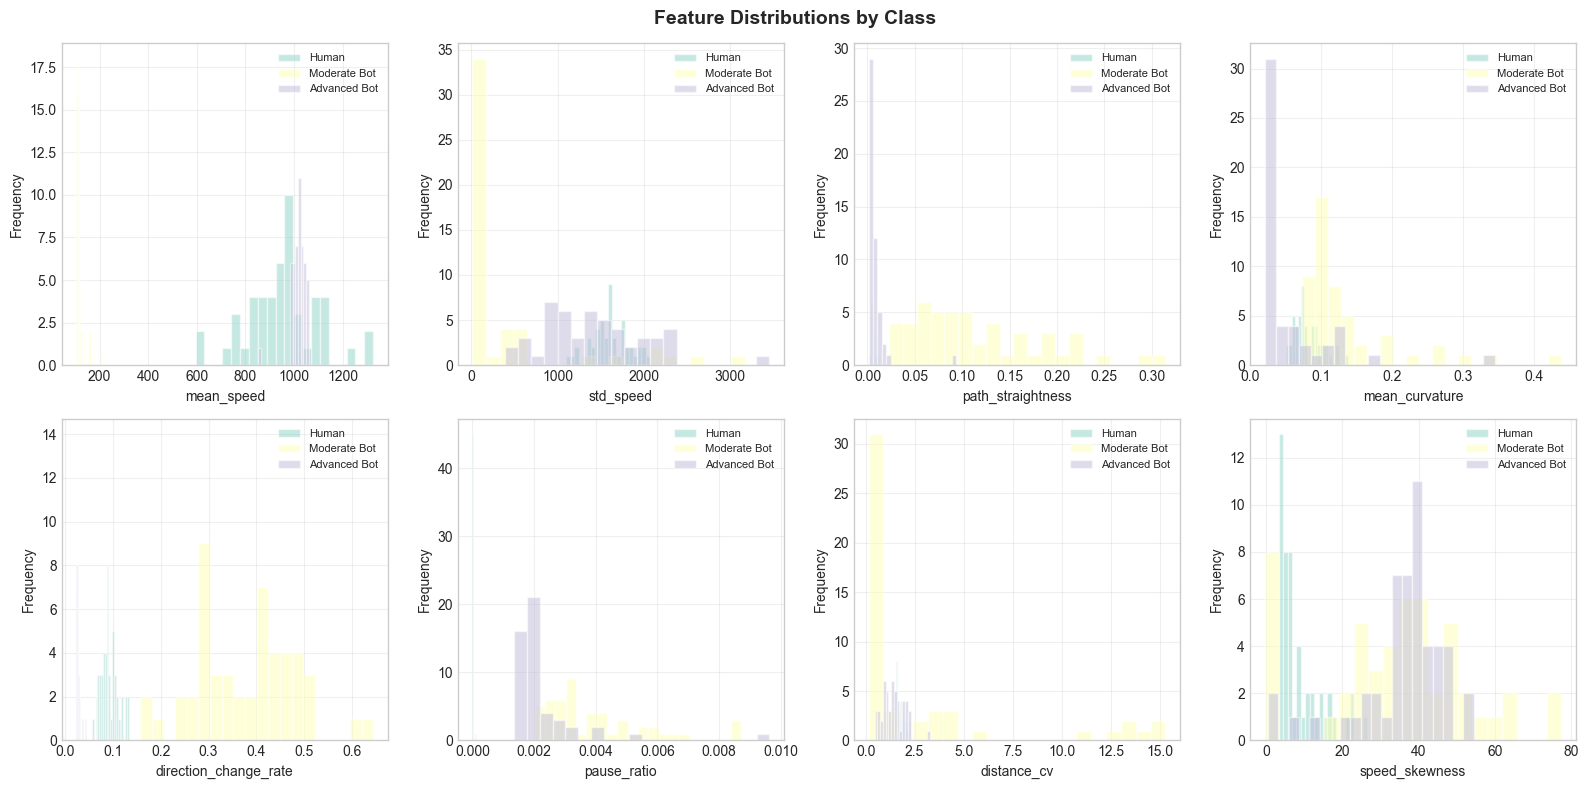

In [25]:
# Select key features to visualize
key_features = [
    'mean_speed', 'std_speed', 'path_straightness', 'mean_curvature',
    'direction_change_rate', 'pause_ratio', 'distance_cv', 'speed_skewness'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    for label_str in ['human', 'moderate_bot', 'advanced_bot']:
        subset = features_df[features_df['label_str'] == label_str][feature]
        ax.hist(subset, bins=20, alpha=0.5, label=label_str.replace('_', ' ').title())
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Correlations

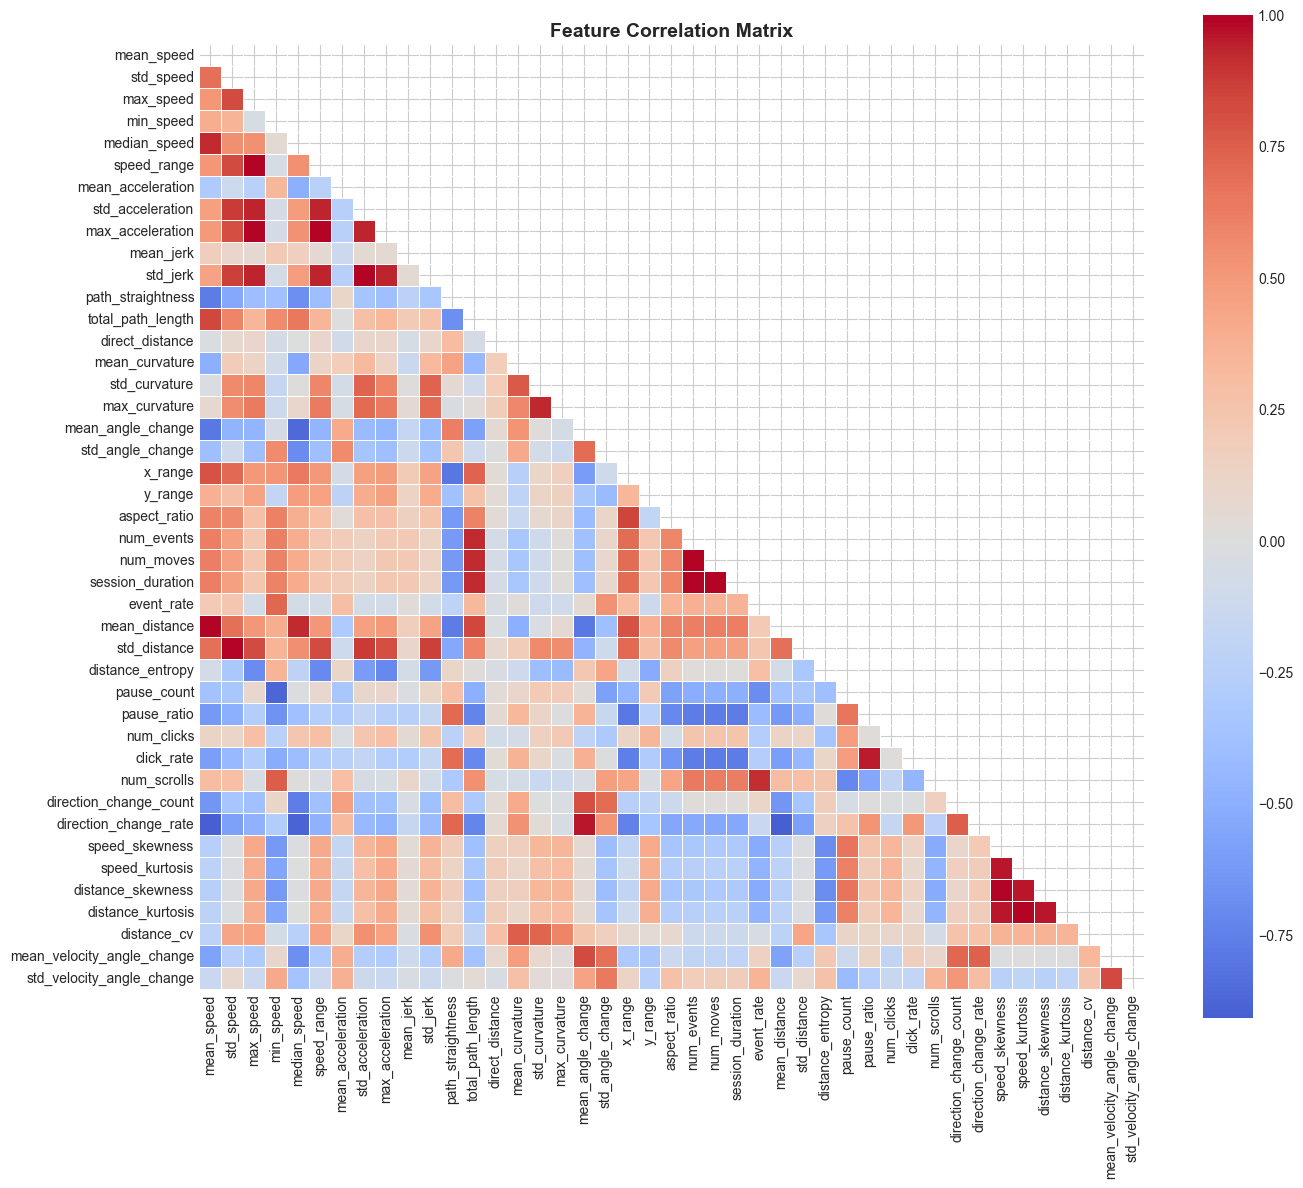

In [26]:
# Correlation matrix
plt.figure(figsize=(14, 12))
corr_matrix = features_df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Find highly correlated features (for potential removal)
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((
                feature_cols[i],
                feature_cols[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Highly correlated feature pairs (|r| > {high_corr_threshold}):")
for f1, f2, corr in high_corr_pairs:
    print(f"  {f1} <-> {f2}: {corr:.3f}")

Highly correlated feature pairs (|r| > 0.9):
  mean_speed <-> median_speed: 0.920
  mean_speed <-> mean_distance: 1.000
  mean_speed <-> direction_change_rate: -0.909
  std_speed <-> std_distance: 1.000
  max_speed <-> speed_range: 1.000
  max_speed <-> std_acceleration: 0.936
  max_speed <-> max_acceleration: 0.999
  max_speed <-> std_jerk: 0.936
  median_speed <-> mean_distance: 0.920
  speed_range <-> std_acceleration: 0.936
  speed_range <-> max_acceleration: 0.999
  speed_range <-> std_jerk: 0.936
  std_acceleration <-> max_acceleration: 0.936
  std_acceleration <-> std_jerk: 1.000
  max_acceleration <-> std_jerk: 0.936
  total_path_length <-> num_events: 0.924
  total_path_length <-> num_moves: 0.925
  total_path_length <-> session_duration: 0.925
  std_curvature <-> max_curvature: 0.926
  mean_angle_change <-> direction_change_rate: 0.959
  num_events <-> num_moves: 1.000
  num_events <-> session_duration: 1.000
  num_moves <-> session_duration: 1.000
  event_rate <-> num_scroll

from sklearn.ensemble import RandomForestClassifier

# Prepare data (NO SCALING HERE - scaling must happen inside CV to avoid data leakage)
X = features_df[feature_cols].values
y = features_df['label'].values

# Train Random Forest for feature importance (RF doesn't require scaling)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Features by Random Forest Importance:")
print(importance_df.head(15).to_string(index=False))

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Prepare data
X = features_df[feature_cols].values
y = features_df['label'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

# Get feature importances
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Features by Random Forest Importance:")
print(importance_df.head(15).to_string(index=False))

Top 15 Features by Random Forest Importance:
                  feature  importance
                  x_range    0.157918
              num_scrolls    0.132628
              pause_count    0.132003
              pause_ratio    0.110021
             aspect_ratio    0.077101
               event_rate    0.066947
               click_rate    0.061976
                min_speed    0.052896
           speed_skewness    0.038150
        distance_skewness    0.021782
        distance_kurtosis    0.016195
           speed_kurtosis    0.015288
        mean_acceleration    0.013301
                std_speed    0.013247
std_velocity_angle_change    0.011515


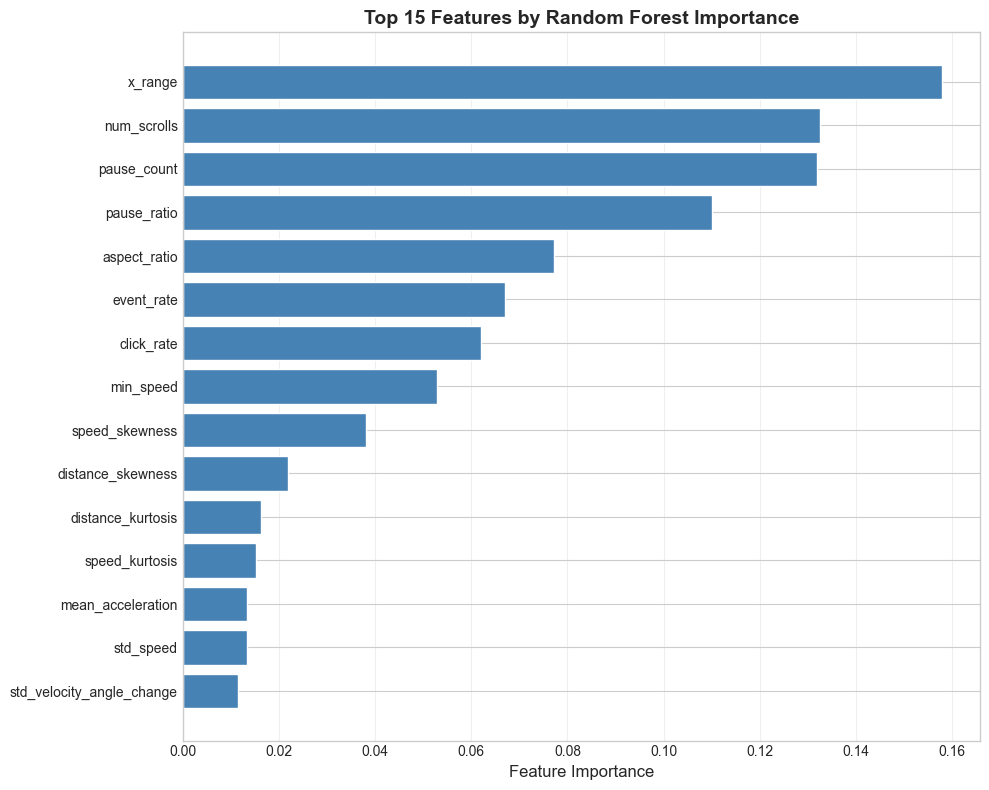

In [29]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_n = 15
top_features = importance_df.head(top_n)

plt.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Features by Random Forest Importance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save feature matrix (unscaled - scaling happens during training to avoid data leakage)
features_df.to_csv(os.path.join(OUTPUT_DIR, 'features.csv'), index=False)
print(f"Saved features to: {os.path.join(OUTPUT_DIR, 'features.csv')}")

# Save feature names
with open(os.path.join(OUTPUT_DIR, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_cols, f)
print(f"Saved feature names to: {os.path.join(OUTPUT_DIR, 'feature_names.pkl')}")

# NOTE: We intentionally do NOT save a scaler here.
# Scaling must be done INSIDE cross-validation folds during training
# to prevent data leakage (test data statistics leaking into training).
print("\nIMPORTANT: Scaler will be fitted during model training inside CV folds.")

## Summary

### Features Extracted
We extracted **40+ features** across four categories:

| Category | Features | Description |
|----------|----------|-------------|
| Kinematic | 11 | Speed, acceleration, jerk statistics |
| Spatial | 10 | Path straightness, curvature, angles |
| Temporal | 9 | Duration, event rate, pauses |
| Behavioral | 10+ | Clicks, scrolls, direction changes |

### Key Discriminating Features
Based on Random Forest importance:
1. **x_range** - Screen coverage patterns differ
2. **num_scrolls** - Different scrolling behavior
3. **pause_count** / **pause_ratio** - Natural pauses in human movement
4. **aspect_ratio** - Movement shape characteristics

### Important Note on Data Leakage
We do NOT scale features in this notebook. Scaling must happen INSIDE cross-validation 
folds during training. If you scale on the full dataset before splitting, test data 
statistics leak into training, causing artificially inflated performance metrics.

### Next Steps
Continue to **Part 3: Model Training** to build classification models.

## Summary

### Features Extracted
We extracted **40+ features** across four categories:

| Category | Features | Description |
|----------|----------|-------------|
| Kinematic | 11 | Speed, acceleration, jerk statistics |
| Spatial | 10 | Path straightness, curvature, angles |
| Temporal | 9 | Duration, event rate, pauses |
| Behavioral | 10+ | Clicks, scrolls, direction changes |

### Key Discriminating Features
Based on Random Forest importance:
1. **direction_change_rate** - Humans change direction more frequently
2. **total_path_length** - Humans generate longer, more exploratory paths
3. **median_speed** - Different speed profiles
4. **pause_ratio** - Natural pauses in human movement
5. **distance_cv** - Coefficient of variation in step sizes

### Next Steps
Continue to **Part 3: Model Training** to build classification models.